# Calving Fronts

* Description: Time-evolving Antarctic calving fronts from observations.
* Original Data Source: https://zenodo.org/records/5903643
* Reference: https://www.nature.com/articles/s41586-022-05037-w
* OSC entry: https://opensciencedata.esa.int/products/antarctic-ice-shelf-calving-fronts/collection
* License: CC-BY-4.0
* Repo Folder: ./datasets/calving_fronts

In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet'

In [28]:
gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)
gdf['area'] = gdf.area

In [29]:
largest_polygon = gdf.sort_values(['time', 'area'], ascending=False).groupby('time').first()
largest_polygon

,geometry,area
time,,
1997-10-01,"POLYGON ((2750273 -284633, 2750153 -284753, 27...",1.365215e+13
2000-03-14,"POLYGON ((2750753 -284153, 2750633 -284273, 27...",1.363662e+13
2000-10-01,"POLYGON ((2750753 -286793, 2750633 -286913, 27...",1.362348e+13
2001-03-15,"POLYGON ((2750513 -283913, 2750393 -284033, 27...",1.361862e+13
2002-03-15,"POLYGON ((2750753 -283913, 2750633 -284033, 27...",1.361781e+13
2003-03-15,"POLYGON ((2750993 -283673, 2750873 -283793, 27...",1.361558e+13
2004-03-14,"POLYGON ((2751233 -283673, 2751113 -283793, 27...",1.361330e+13
2005-03-15,"POLYGON ((2751473 -283433, 2751353 -283553, 27...",1.361590e+13
2006-03-15,"POLYGON ((2751713 -282713, 2751593 -282833, 27...",1.361750e+13


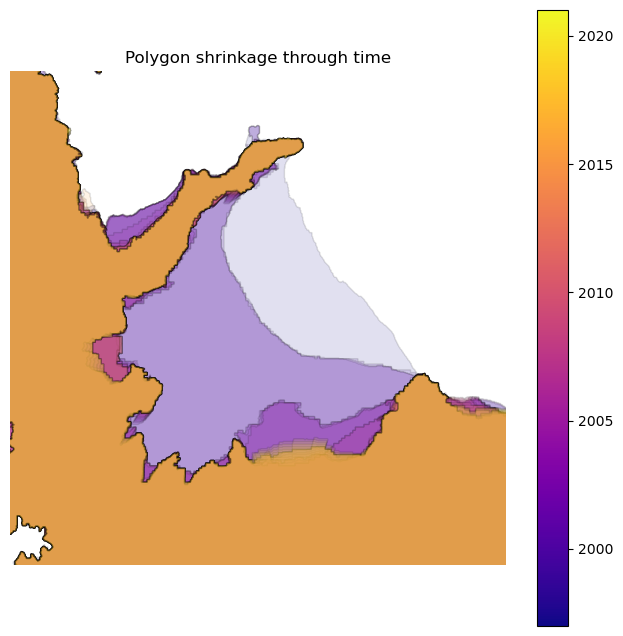

In [30]:
fronts = largest_polygon.reset_index().sort_values("time")
fronts["year"] = pd.to_datetime(fronts["time"]).dt.year

changed = fronts.geometry.iloc[0].symmetric_difference(fronts.geometry.iloc[-1])
zoom = max(getattr(changed, "geoms", [changed]), key=lambda geom: geom.area)
xmin, ymin, xmax, ymax = zoom.bounds
pad = max(xmax - xmin, ymax - ymin) * 0.25

ax = fronts.plot(
    column="year",
    cmap="plasma",
    alpha=0.12,
    edgecolor="black",
    linewidth=1,
    legend=True,
    figsize=(8, 8),
)

ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set(title="Polygon shrinkage through time", aspect="equal")
ax.set_axis_off()
plt.show()